In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"  # 🔥 This line disables OpenBLAS thread error

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans as KMeans
from joblib import parallel_backend

from sklearn.preprocessing import StandardScaler



In [ ]:
df = pd.read_csv('customer_data.csv')
df.head()


,CustomerID,Gender,Age,Annual Income (k₹),Spending Score (1–100)
0,1,Male,18,10,1
1,2,Female,19,11,2
2,3,Male,20,12,3
3,4,Female,21,13,4
4,5,Male,22,14,5


In [ ]:
df.isnull().sum()  # check missing values
df.describe()


,CustomerID,Age,Annual Income (k₹),Spending Score (1–100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,42.500000,43.000000,50.500000
std,57.879185,14.467083,19.568203,28.938507
min,1.000000,18.000000,10.000000,1.000000
25%,50.750000,30.000000,26.000000,25.750000
50%,100.500000,42.500000,43.000000,50.500000
75%,150.250000,55.000000,59.250000,75.250000
max,200.000000,67.000000,79.000000,100.000000


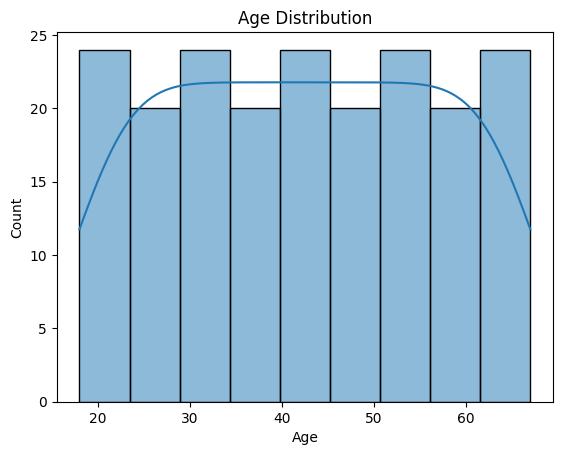

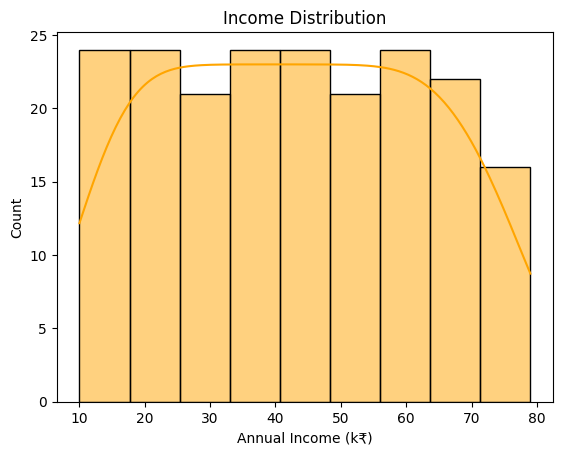

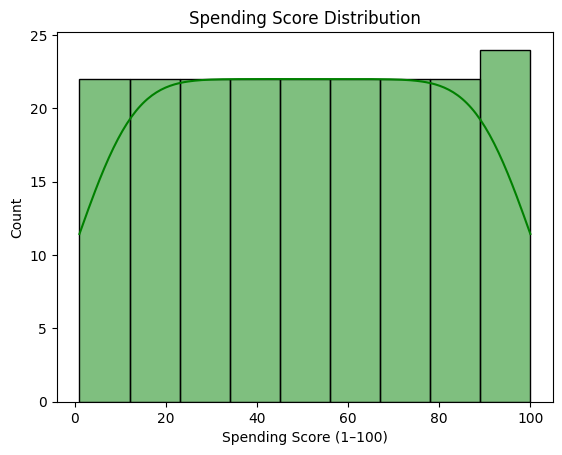

In [ ]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

sns.histplot(df['Annual Income (k₹)'], kde=True, color='orange')
plt.title("Income Distribution")
plt.show()

sns.histplot(df['Spending Score (1–100)'], kde=True, color='green')
plt.title("Spending Score Distribution")
plt.show()


In [ ]:
def segment_customer(row):
    income = row['Annual Income (k₹)']
    score = row['Spending Score (1–100)']
    
    if income >= 60 and score >= 60:
        return 'Premium'
    elif income < 40 and score < 40:
        return 'Budget'
    elif income >= 60 and score < 40:
        return 'Careless'
    else:
        return 'Value Seeker'

df['Segment'] = df.apply(segment_customer, axis=1)
df.head()


,CustomerID,Gender,Age,Annual Income (k₹),Spending Score (1–100),Segment
0,1,Male,18,10,1,Budget
1,2,Female,19,11,2,Budget
2,3,Male,20,12,3,Budget
3,4,Female,21,13,4,Budget
4,5,Male,22,14,5,Budget


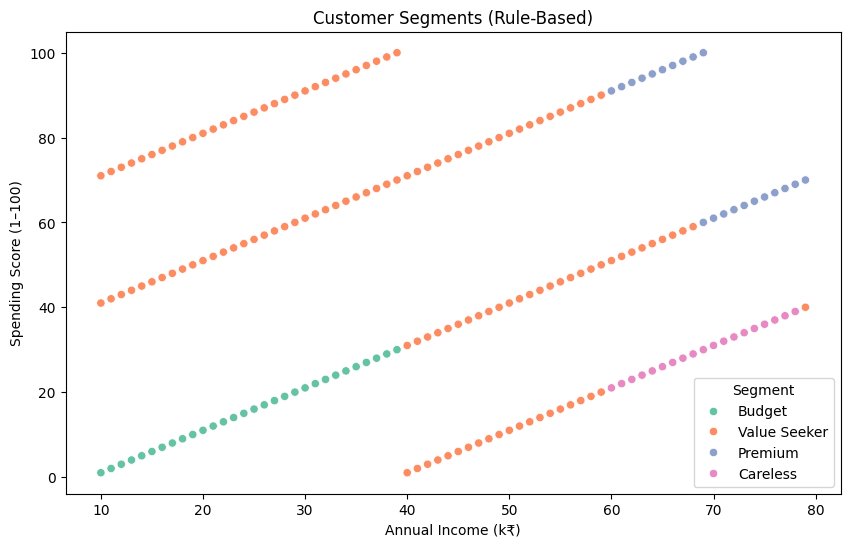

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Annual Income (k₹)', 
    y='Spending Score (1–100)', 
    hue='Segment', 
    data=df, 
    palette='Set2'
)
plt.title("Customer Segments (Rule-Based)")
plt.savefig('plots/segment_plot.png')
plt.show()


In [ ]:
# Save the new dataframe with segments to CSV
df.to_csv('segmented_customers.csv', index=False)



In [ ]:
summary = """
Project: Customer Segmentation Analysis

Objective:
Segment customers based on their Annual Income and Spending Score using rule-based logic.

Segments:
- Premium: High income, high spending
- Budget: Low income, low spending
- Careless: High income, low spending
- Value Seeker: Low income, high spending

Tools:
- Python (pandas, seaborn, matplotlib)

Insights:
These segments can help businesses plan targeted marketing campaigns and personalized offers.

Created by: Pranita Yadav
"""

with open("README.txt", "w") as file:
    file.write(summary)
